In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once Google Drive is mounted, you can access your files. Here's an example of how to load a CSV file using pandas. Make sure to replace `'Your_File_Path_Here/your_file.csv'` with the actual path to your file in Google Drive.

In [8]:
import requests
import os
import zipfile
import tempfile
import shutil # For moving files/directories

# --- Data Download ---
# Replace with the actual URLs of the zip files you want to download
zip_urls = [
    'https://d36ajqhpoeuszk.cloudfront.net/SEU-ALLEN_full_SWC_CCFv3.zip',
    'https://d36ajqhpoeuszk.cloudfront.net/SEU-ALLEN_local_SWC_CCFv3.zip',
    'https://d36ajqhpoeuszk.cloudfront.net/ION_Hipp_full_SWC_CCFv3.zip',
    'https://d36ajqhpoeuszk.cloudfront.net/ION_Hypo_full_SWC_CCFv3.zip',
    'https://d36ajqhpoeuszk.cloudfront.net/ION_PFC_full_SWC_CCFv3.zip',
    'https://d36ajqhpoeuszk.cloudfront.net/ION_PFC_full_SWC_CCFv3.zip',
    'https://d36ajqhpoeuszk.cloudfront.net/MouseLight_full_SWC_CCFv3.zip'
    # Duplicate will still be processed unless its unzipped folder exists
]

# Base folder in your Google Drive where you want to save the unzipped files
# This path assumes your Drive is mounted at '/content/drive'
base_destination_folder = '/content/drive/MyDrive/NeuroVLM/SWCs/'

# Ensure the base destination folder exists in Google Drive
os.makedirs(base_destination_folder, exist_ok=True)

print(f"Attempting to download and unzip files to '{base_destination_folder}'...")

processed_zips = set() # To keep track of unique zip file names to avoid redundant processing of duplicates

for zip_url in zip_urls:
    file_name = os.path.basename(zip_url)

    # Derive the folder name where contents will be extracted
    # e.g., 'SEU-ALLEN_full_SWC_CCFv3' from 'SEU-ALLEN_full_SWC_CCFv3.zip'
    unzipped_folder_name = os.path.splitext(file_name)[0]
    final_destination_path = os.path.join(base_destination_folder, unzipped_folder_name)

    if file_name in processed_zips:
        print(f"\n--- Skipping duplicate URL: {file_name} (already processed) ---")
        continue

    if os.path.exists(final_destination_path) and os.listdir(final_destination_path):
        print(f"\n--- Skipping: {file_name} --- ")
        print(f"Contents for '{unzipped_folder_name}' already exist in '{final_destination_path}'.")
        processed_zips.add(file_name)
        continue

    temp_zip_path = None # Initialize to None

    print(f"\n--- Processing: {file_name} ---")
    try:
        # Create a temporary file to store the downloaded zip
        with tempfile.NamedTemporaryFile(delete=False, suffix=f'_{file_name}') as temp_zip_file:
            temp_zip_path = temp_zip_file.name
            print(f"Downloading '{file_name}' to temporary location: '{temp_zip_path}'")
            response = requests.get(zip_url, stream=True)
            response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)

            for chunk in response.iter_content(chunk_size=8192):
                temp_zip_file.write(chunk)

        print(f"Successfully downloaded zip to temporary location: '{temp_zip_path}'")

        # Create a temporary directory to extract contents
        with tempfile.TemporaryDirectory() as temp_extract_dir:
            print(f"Extracting contents of '{temp_zip_path}' to temporary directory '{temp_extract_dir}'...")
            with zipfile.ZipFile(temp_zip_path, 'r') as zip_ref:
                zip_ref.extractall(temp_extract_dir)

            # Create the final destination path for this specific zip's contents
            os.makedirs(final_destination_path, exist_ok=True)
            print(f"Moving extracted files from '{temp_extract_dir}' to Google Drive folder '{final_destination_path}'...")

            # Move extracted contents from the temporary directory to the final destination
            for item in os.listdir(temp_extract_dir):
                s = os.path.join(temp_extract_dir, item)
                d = os.path.join(final_destination_path, item)
                if os.path.isdir(s):
                    shutil.copytree(s, d, dirs_exist_ok=True)
                else:
                    shutil.copy2(s, d)

        print(f"Successfully unzipped and saved contents of '{file_name}' to '{final_destination_path}'")
        processed_zips.add(file_name)

    except requests.exceptions.RequestException as e:
        print(f"Error downloading '{file_name}': {e}")
    except zipfile.BadZipFile:
        print(f"Error: The downloaded file '{file_name}' is not a valid zip file.")
    except Exception as e:
        print(f"An unexpected error occurred for '{file_name}': {e}")
    finally:
        # Clean up the temporary zip file if it exists
        if temp_zip_path and os.path.exists(temp_zip_path):
            os.remove(temp_zip_path)
            print(f"Cleaned up temporary zip file: '{temp_zip_path}'")

print("\n--- All files processed ---")

Attempting to download and unzip files to '/content/drive/MyDrive/NeuroVLM/SWCs/'...

--- Skipping: SEU-ALLEN_full_SWC_CCFv3.zip --- 
Contents for 'SEU-ALLEN_full_SWC_CCFv3' already exist in '/content/drive/MyDrive/NeuroVLM/SWCs/SEU-ALLEN_full_SWC_CCFv3'.

--- Skipping: SEU-ALLEN_local_SWC_CCFv3.zip --- 
Contents for 'SEU-ALLEN_local_SWC_CCFv3' already exist in '/content/drive/MyDrive/NeuroVLM/SWCs/SEU-ALLEN_local_SWC_CCFv3'.

--- Skipping: ION_Hipp_full_SWC_CCFv3.zip --- 
Contents for 'ION_Hipp_full_SWC_CCFv3' already exist in '/content/drive/MyDrive/NeuroVLM/SWCs/ION_Hipp_full_SWC_CCFv3'.

--- Skipping: ION_Hypo_full_SWC_CCFv3.zip --- 
Contents for 'ION_Hypo_full_SWC_CCFv3' already exist in '/content/drive/MyDrive/NeuroVLM/SWCs/ION_Hypo_full_SWC_CCFv3'.

--- Skipping: ION_PFC_full_SWC_CCFv3.zip --- 
Contents for 'ION_PFC_full_SWC_CCFv3' already exist in '/content/drive/MyDrive/NeuroVLM/SWCs/ION_PFC_full_SWC_CCFv3'.

--- Skipping duplicate URL: ION_PFC_full_SWC_CCFv3.zip (already proc

In [ ]:
import os

neuro_vlm_folder = '/content/drive/MyDrive/NeuroVLM/SWCs/'

print(f"Contents of '{neuro_vlm_folder}':")
if os.path.exists(neuro_vlm_folder):
    for item in os.listdir(neuro_vlm_folder):
        print(f"- {item}")
else:
    print(f"Error: Folder '{neuro_vlm_folder}' not found in Google Drive.")

Contents of '/content/drive/MyDrive/NeuroVLM/SWCs/':
- SEU-ALLEN_full_SWC_CCFv3
- SEU-ALLEN_local_SWC_CCFv3
- ION_Hipp_full_SWC_CCFv3
- ION_Hypo_full_SWC_CCFv3
- ION_PFC_full_SWC_CCFv3
- MouseLight_full_SWC_CCFv3


In [2]:
neuro_vlm_folder = 'SWCs/'

In [1]:
pip install neurom

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/536.6 kB ? eta -:--:--
     -------------------------------------- 536.6/536.6 kB 5.8 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/832.3 kB ? eta -:--:--
   ------------------------------------- -- 786.4/832.3 kB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 832.3/832.3 kB 2.7 MB/s eta 0:00:00
  Created wheel for neurom: filename=neurom-4.0.5-py3-none-any.whl size=110156 sha256=a57f7e0fdef5559bdb234b1a53997595384b641fd531d85b1dfc6e272cedb48c
  Stored in directory: c:\users\banerjee\appdata\local\pi

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Now that `neurom` is installed, let's list all the `.swc` files available in the folders you've downloaded. This will help us identify files to process.

In [3]:
import os

swc_files = []
for root, dirs, files in os.walk(neuro_vlm_folder):
    for file in files:
        if file.endswith('.swc'):
            swc_files.append(os.path.join(root, file))

print(f"Found {len(swc_files)} SWC files:")
for swc_file in swc_files[:10]: # Print first 10 for brevity
    print(f"- {swc_file}")

if swc_files:
    example_swc_file = swc_files[0]
    print(f"\nUsing the first found SWC file for demonstration: {example_swc_file}")
else:
    print("No SWC files found. Please ensure the downloaded folders contain .swc files.")

Found 182329 SWC files:
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_002_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_003_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_004_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_005_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_006_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_007_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_008_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_009_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_010_CCFv3.swc
- SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_012_CCFv3.swc

Using the first found SWC file for demonstration: SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_002_CC

Let's load the first SWC file using `neurom` and extract some basic information. `neurom` treats SWC files as `Neuron` objects, allowing easy access to its morphological properties.

Successfully loaded SWC file: SWCs/ION_Hipp_full_SWC_CCFv3\ION_Hipp_full_SWC_CCFv3\ION_full_200335_002_CCFv3.swc

Number of neurites: 1
Total length of morphology: 83306.43 units


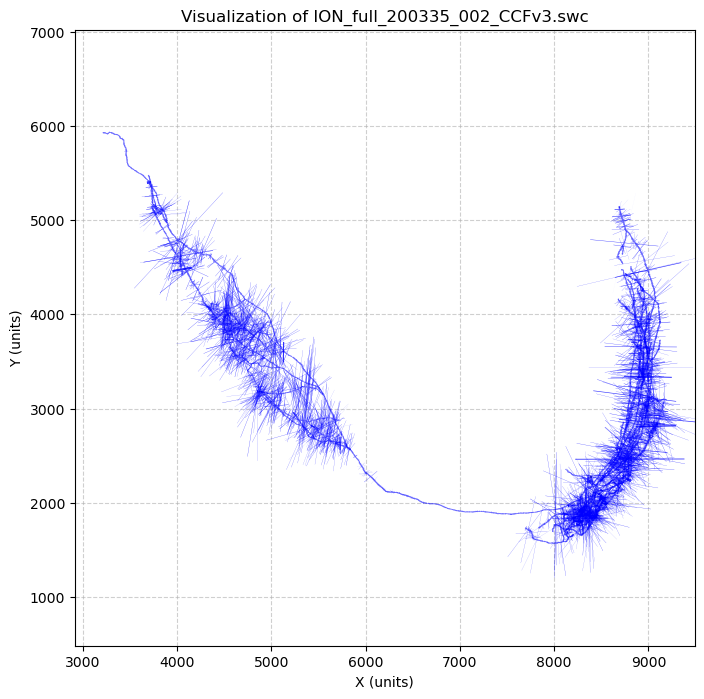

In [4]:
import neurom as nm
from neurom import view
import matplotlib.pyplot as plt
import os

if 'example_swc_file' in locals() and example_swc_file:
    try:
        # Load the morphology
        morph = nm.load_morphology(example_swc_file)
        print(f"Successfully loaded SWC file: {example_swc_file}")

        # Print basic properties
        print(f"\nNumber of neurites: {len(morph.neurites)}")

        # Get total length statistic
        total_length = nm.get('total_length', morph)
        print(f"Total length of morphology: {total_length:.2f} units")

        # Improved Visualization
        fig, ax = plt.subplots(figsize=(8, 8))

        # plot_morph uses the XY plane by default; we'll force it to show the full extent
        view.plot_morph(morph, ax=ax)

        ax.set_title(f"Visualization of {os.path.basename(example_swc_file)}")
        ax.set_xlabel('X (units)')
        ax.set_ylabel('Y (units)')
        ax.axis('equal') # Ensure 1:1 aspect ratio
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    except Exception as e:
        print(f"Error loading or processing {example_swc_file}: {e}")
else:
    print("Cannot load example SWC file as no files were found or selected.")

### Voxelizing SWC to 3D Volumes
To compare vector data with raw microscopy, we need to convert the SWC into a voxel grid (rasterization). The following code creates a small 3D volume around the neuron's bounding box.

In [5]:
import numpy as np

def get_neuron_mask(morph, voxel_size=10.0):
    """Generates a binary 3D mask from morphology nodes."""
    # Get all point coordinates (X, Y, Z)
    points = morph.points[:, :3]

    # Calculate bounding box
    min_coords = np.min(points, axis=0)
    max_coords = np.max(points, axis=0)

    # Determine grid dimensions
    shape = ((max_coords - min_coords) / voxel_size).astype(int) + 1
    mask = np.zeros(shape, dtype=np.uint8)

    # Map points to grid indices
    indices = ((points - min_coords) / voxel_size).astype(int)

    # Fill mask (simple point-based voxelization)
    for idx in indices:
        mask[idx[0], idx[1], idx[2]] = 1

    return mask, min_coords

# Generate a mask for the example morphology
voxel_res = 20.0 # Adjust resolution as needed (units per voxel)
mask, origin = get_neuron_mask(morph, voxel_size=voxel_res)

print(f"Created 3D mask with shape: {mask.shape}")
print(f"Mask origin in CCFv3 space: {origin}")
print(f"Number of occupied voxels: {np.sum(mask)}")

Created 3D mask with shape: (299, 219, 208)
Mask origin in CCFv3 space: [3213.34 1570.36 5750.58]
Number of occupied voxels: 5416


### Visualizing the Voxelized 3D Mask
Since the mask is a 3D volume, we can visualize it by projecting the maximum values along each axis (X, Y, and Z).

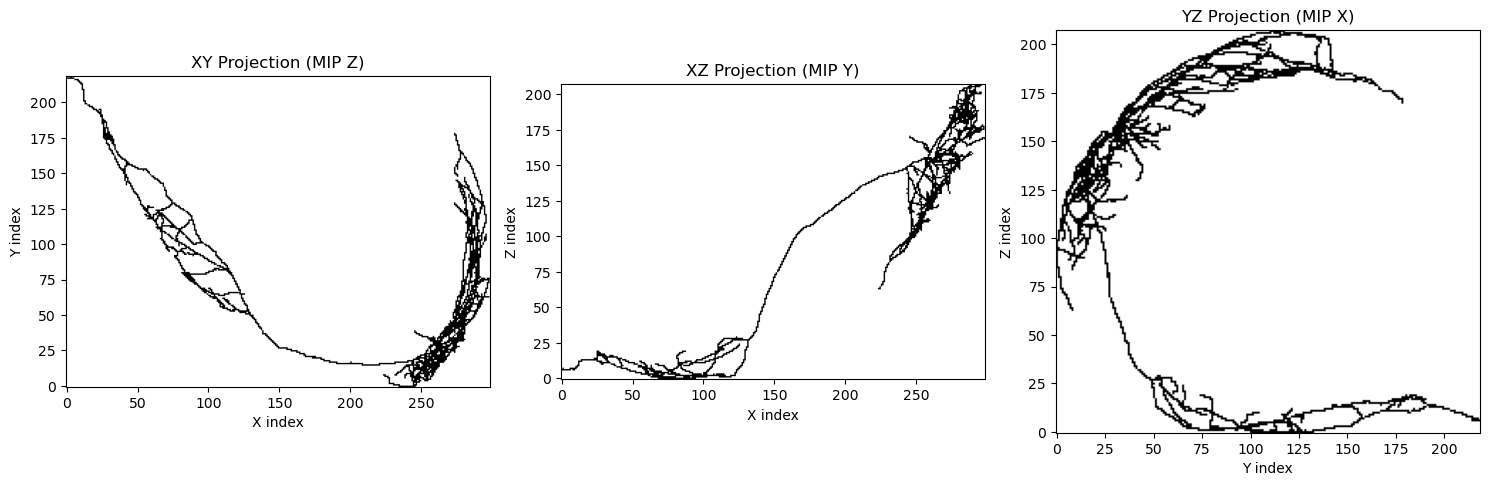

In [6]:
import matplotlib.pyplot as plt

# Calculate Maximum Intensity Projections (MIPs)
mip_z = np.max(mask, axis=2) # Projection onto XY plane
mip_y = np.max(mask, axis=1) # Projection onto XZ plane
mip_x = np.max(mask, axis=0) # Projection onto YZ plane

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mip_z.T, origin='lower', cmap='gray_r')
axes[0].set_title('XY Projection (MIP Z)')
axes[0].set_xlabel('X index')
axes[0].set_ylabel('Y index')

axes[1].imshow(mip_y.T, origin='lower', cmap='gray_r')
axes[1].set_title('XZ Projection (MIP Y)')
axes[1].set_xlabel('X index')
axes[1].set_ylabel('Z index')

axes[2].imshow(mip_x.T, origin='lower', cmap='gray_r')
axes[2].set_title('YZ Projection (MIP X)')
axes[2].set_xlabel('Y index')
axes[2].set_ylabel('Z index')

plt.tight_layout()
plt.show()

This code snippet first defines the URL of the zip file and the desired destination folder within your Google Drive. It then downloads the file using the `requests` library and saves it to the specified path in your Drive.